In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import stats
%matplotlib inline

In [2]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
df.drop(columns=['TotalCharges'], inplace=True)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes


In [10]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [11]:
df['Partner'].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [12]:
df['Dependents'].value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

In [13]:
df['PhoneService'].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

In [14]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [15]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [16]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [17]:
df['OnlineBackup'].value_counts()

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

In [18]:
df['DeviceProtection'].value_counts()

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

In [19]:
df['TechSupport'].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [20]:
df['StreamingTV'].value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

In [21]:
df['StreamingMovies'].value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [22]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [23]:
df['PaperlessBilling'].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [24]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [25]:
table = pd.crosstab(df['gender'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn     No  Yes
gender           
Female  2549  939
Male    2625  930
Chi2: 0.48, p-value: 0.4866, Degrees of freedom: 1


In [29]:
df.head()

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,7590-VHVEG,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,3668-QPYBK,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,7795-CFOCW,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,9237-HQITU,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes


In [30]:
df.drop(columns=['customerID'],inplace=True)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes


In [31]:
table = pd.crosstab(df['Partner'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn      No   Yes
Partner            
No       2441  1200
Yes      2733   669
Chi2: 158.73, p-value: 0.0000, Degrees of freedom: 1


In [32]:
table = pd.crosstab(df['Dependents'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn         No   Yes
Dependents            
No          3390  1543
Yes         1784   326
Chi2: 189.13, p-value: 0.0000, Degrees of freedom: 1


In [33]:
table = pd.crosstab(df['PhoneService'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn           No   Yes
PhoneService            
No             512   170
Yes           4662  1699
Chi2: 0.92, p-value: 0.3388, Degrees of freedom: 1


In [34]:
df.drop(columns=['PhoneService'], inplace=True)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes


In [35]:
table = pd.crosstab(df['MultipleLines'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn               No  Yes
MultipleLines              
No                2541  849
No phone service   512  170
Yes               2121  850
Chi2: 11.33, p-value: 0.0035, Degrees of freedom: 2


In [36]:
table = pd.crosstab(df['InternetService'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113
Chi2: 732.31, p-value: 0.0000, Degrees of freedom: 2


In [37]:
table = pd.crosstab(df['OnlineSecurity'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn                  No   Yes
OnlineSecurity                 
No                   2037  1461
No internet service  1413   113
Yes                  1724   295
Chi2: 850.00, p-value: 0.0000, Degrees of freedom: 2


In [38]:
table = pd.crosstab(df['OnlineBackup'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn                  No   Yes
OnlineBackup                   
No                   1855  1233
No internet service  1413   113
Yes                  1906   523
Chi2: 601.81, p-value: 0.0000, Degrees of freedom: 2


In [39]:
table = pd.crosstab(df['DeviceProtection'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn                  No   Yes
DeviceProtection               
No                   1884  1211
No internet service  1413   113
Yes                  1877   545
Chi2: 558.42, p-value: 0.0000, Degrees of freedom: 2


In [40]:
table = pd.crosstab(df['TechSupport'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn                  No   Yes
TechSupport                    
No                   2027  1446
No internet service  1413   113
Yes                  1734   310
Chi2: 828.20, p-value: 0.0000, Degrees of freedom: 2


In [41]:
table = pd.crosstab(df['StreamingTV'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn                  No  Yes
StreamingTV                   
No                   1868  942
No internet service  1413  113
Yes                  1893  814
Chi2: 374.20, p-value: 0.0000, Degrees of freedom: 2


In [42]:
table = pd.crosstab(df['StreamingMovies'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn                  No  Yes
StreamingMovies               
No                   1847  938
No internet service  1413  113
Yes                  1914  818
Chi2: 375.66, p-value: 0.0000, Degrees of freedom: 2


In [43]:
table = pd.crosstab(df['Contract'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48
Chi2: 1184.60, p-value: 0.0000, Degrees of freedom: 2


In [44]:
table = pd.crosstab(df['PaperlessBilling'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn               No   Yes
PaperlessBilling            
No                2403   469
Yes               2771  1400
Chi2: 258.28, p-value: 0.0000, Degrees of freedom: 1


In [45]:
table = pd.crosstab(df['PaymentMethod'], df['Churn'])
print(table)

chi2, p, dof, expected = chi2_contingency(table)
alpha = 0.05
print(f'Chi2: {chi2:.2f}, p-value: {p:.4f}, Degrees of freedom: {dof}')

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308
Chi2: 648.14, p-value: 0.0000, Degrees of freedom: 3


In [46]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Partner"]=le.fit_transform(df["Partner"])
df["Dependents"]=le.fit_transform(df["Dependents"])
df["MultipleLines"]=le.fit_transform(df["MultipleLines"])
df["InternetService"]=le.fit_transform(df["InternetService"])
df["OnlineSecurity"]=le.fit_transform(df["OnlineSecurity"])
df["OnlineBackup"]=le.fit_transform(df["OnlineBackup"])
df["DeviceProtection"]=le.fit_transform(df["DeviceProtection"])
df["TechSupport"]=le.fit_transform(df["TechSupport"])
df["StreamingTV"]=le.fit_transform(df["StreamingTV"])
df["StreamingMovies"]=le.fit_transform(df["StreamingMovies"])
df["Contract"]=le.fit_transform(df["Contract"])
df["PaperlessBilling"]=le.fit_transform(df["PaperlessBilling"])
df["PaymentMethod"]=le.fit_transform(df["PaymentMethod"])
df["Churn"]=le.fit_transform(df["Churn"])
df

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,1,0,1,1,0,0,2,0,0,0,0,0,1,2,29.85,0
1,0,0,0,34,0,0,2,0,2,0,0,0,1,0,3,56.95,0
2,0,0,0,2,0,0,2,2,0,0,0,0,0,1,3,53.85,1
3,0,0,0,45,1,0,2,0,2,2,0,0,1,0,0,42.30,0
4,0,0,0,2,0,1,0,0,0,0,0,0,0,1,2,70.70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,2,0,2,0,2,2,2,2,1,1,3,84.80,0
7039,0,1,1,72,2,1,0,2,2,0,2,2,1,1,1,103.20,0
7040,0,1,1,11,1,0,2,0,0,0,0,0,0,1,2,29.60,0
7041,1,1,0,4,2,1,0,0,0,0,0,0,0,1,3,74.40,1


In [47]:
df.shape

(7043, 17)

In [48]:
sample_size=3000
x=np.random.choice(df['SeniorCitizen'],sample_size)
y=np.random.choice(df['Churn'],sample_size)
print(x)
print(y)

[0 0 1 ... 1 0 0]
[0 0 1 ... 1 0 0]


In [49]:
t_stat, p_value = stats.ttest_ind(x,y)
print('t-statistic:', round(t_stat, 2))
print('p-value:', round(p_value, 4))

t-statistic: -7.65
p-value: 0.0


In [50]:
df.drop(columns=['SeniorCitizen'], inplace=True)
df.head()

,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,1,0,1,1,0,0,2,0,0,0,0,0,1,2,29.85,0
1,0,0,34,0,0,2,0,2,0,0,0,1,0,3,56.95,0
2,0,0,2,0,0,2,2,0,0,0,0,0,1,3,53.85,1
3,0,0,45,1,0,2,0,2,2,0,0,1,0,0,42.30,0
4,0,0,2,0,1,0,0,0,0,0,0,0,1,2,70.70,1


In [51]:
sample_size=3000
x=np.random.choice(df['tenure'],sample_size)
y=np.random.choice(df['Churn'],sample_size)
print(x)
print(y)

[68 40  9 ... 31 25  8]
[1 1 0 ... 0 0 0]


In [52]:
t_stat, p_value = stats.ttest_ind(x,y)
print('t-statistic:', round(t_stat, 2))
print('p-value:', round(p_value, 4))

t-statistic: 70.26
p-value: 0.0


In [53]:
sample_size=3000
x=np.random.choice(df['MonthlyCharges'],sample_size)
y=np.random.choice(df['Churn'],sample_size)
print(x)
print(y)

[ 50.2   70.5  106.5  ...  70.55 110.    20.65]
[0 0 1 ... 0 1 0]


In [54]:
t_stat, p_value = stats.ttest_ind(x,y)
print('t-statistic:', round(t_stat, 2))
print('p-value:', round(p_value, 4))

t-statistic: 118.41
p-value: 0.0


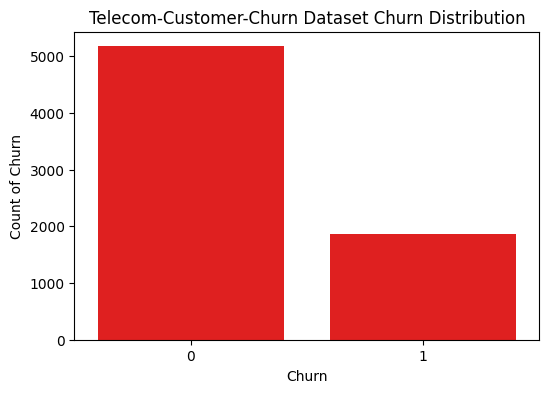

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn",data=df,color='red')
plt.title('Telecom-Customer-Churn Dataset Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count of Churn')
plt.show()

##Churn yes(1) means customer left and no(0) means customer stayed

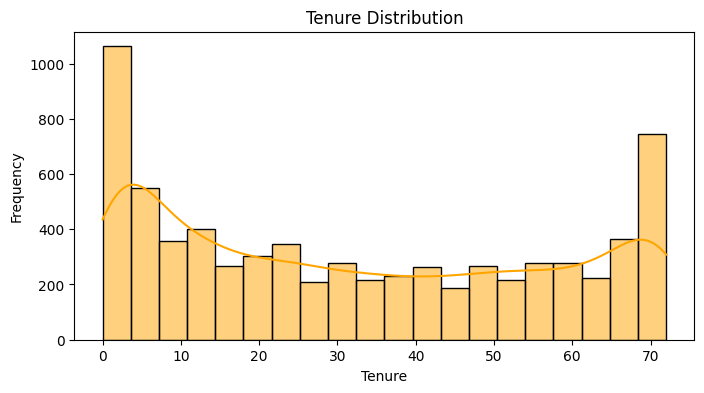

In [56]:
plt.figure(figsize=(8,4))
sns.histplot(df['tenure'],bins=20,kde=True,color='orange')
plt.title('Tenure Distribution')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.show()

# tenure

# Number of months customer company kooda irukanga

#Example:

# 0–10 months customers evlo
# 10–20 months evlo
# 50+ months evlo

#Idhu ellam bars-a kaamikum.

# Important feature (Churn-ku strong impact)

In [57]:
counts=df['InternetService'].value_counts()
counts

#InternetService
#Fiber optic (1)   3096
#DSL  (0)          2421
#No   (2)        1526

InternetService
1    3096
0    2421
2    1526
Name: count, dtype: int64

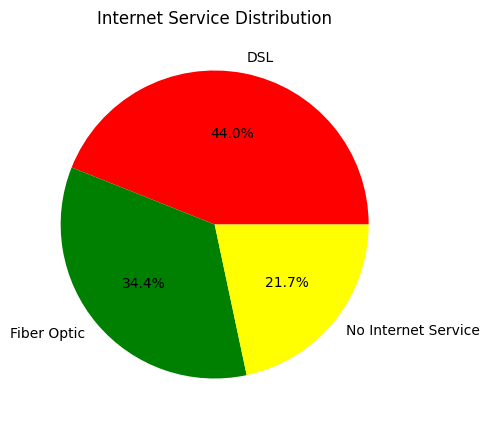

In [58]:
Service_counts = df['InternetService'].value_counts()
plt.figure(figsize=(6,5))
plt.pie(Service_counts, labels=['DSL', 'Fiber Optic','No Internet Service'],colors=['red', 'green','yellow'],autopct='%1.1f%%')
plt.title('Internet Service Distribution')
plt.show()



# Types of Internet Service (Dataset Context)
# DSL

# Telephone line use pannum internet
# Speed konjam medium

# Fiber Optic

# Very high-speed internet
# Cost konjam high

# No

# Customer internet use panna maataanga

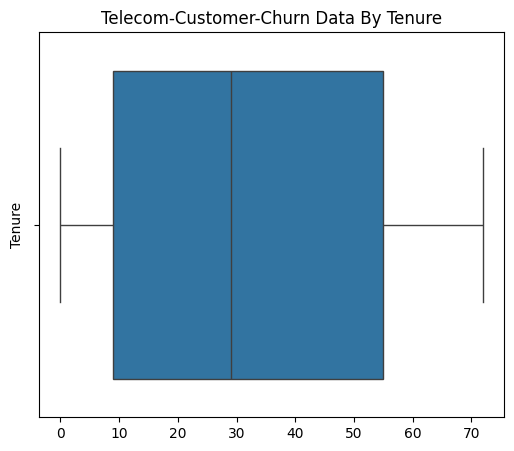

In [59]:
plt.figure(figsize=(6,5))
sns.boxplot(x='tenure', data=df)
plt.title('Telecom-Customer-Churn Data By Tenure')
plt.xlabel('')
plt.ylabel('Tenure')
plt.show()

# tenure

# Number of months customer company kooda irukanga

#Example:

#2 months → New customer

#60 months → Loyal customer

# Important feature (Churn-ku strong impact)

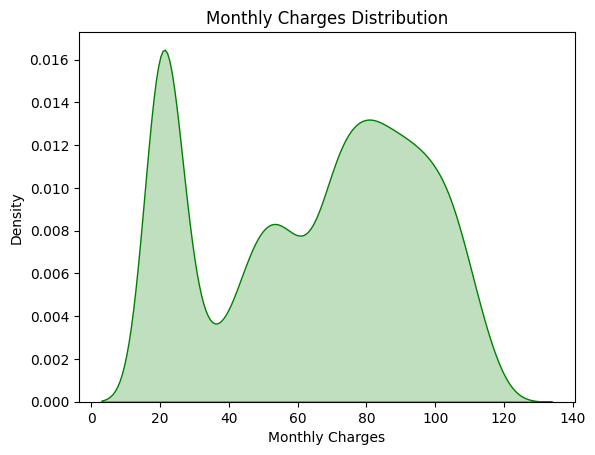

In [60]:
sns.kdeplot(data=df['MonthlyCharges'],color='green',fill=True)
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')
plt.show()

In [61]:
df.shape

(7043, 16)

In [63]:
df.head()

,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,1,0,1,1,0,0,2,0,0,0,0,0,1,2,29.85,0
1,0,0,34,0,0,2,0,2,0,0,0,1,0,3,56.95,0
2,0,0,2,0,0,2,2,0,0,0,0,0,1,3,53.85,1
3,0,0,45,1,0,2,0,2,2,0,0,1,0,0,42.30,0
4,0,0,2,0,1,0,0,0,0,0,0,0,1,2,70.70,1


In [64]:
x=df.drop(["Churn"],axis=1)
y=df["Churn"]
x

,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
0,1,0,1,1,0,0,2,0,0,0,0,0,1,2,29.85
1,0,0,34,0,0,2,0,2,0,0,0,1,0,3,56.95
2,0,0,2,0,0,2,2,0,0,0,0,0,1,3,53.85
3,0,0,45,1,0,2,0,2,2,0,0,1,0,0,42.30
4,0,0,2,0,1,0,0,0,0,0,0,0,1,2,70.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,1,24,2,0,2,0,2,2,2,2,1,1,3,84.80
7039,1,1,72,2,1,0,2,2,0,2,2,1,1,1,103.20
7040,1,1,11,1,0,2,0,0,0,0,0,0,1,2,29.60
7041,1,0,4,2,1,0,0,0,0,0,0,0,1,3,74.40


In [65]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [66]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=sc.fit_transform(x)
x

array([[ 1.03453023, -0.65401193, -1.27744458, ...,  0.8297975 ,
         0.39855772, -1.16032292],
       [-0.96662231, -0.65401193,  0.06632742, ..., -1.20511329,
         1.33486261, -0.25962894],
       [-0.96662231, -0.65401193, -1.23672422, ...,  0.8297975 ,
         1.33486261, -0.36266036],
       ...,
       [ 1.03453023,  1.5290241 , -0.87024095, ...,  0.8297975 ,
         0.39855772, -1.1686319 ],
       [ 1.03453023, -0.65401193, -1.15528349, ...,  0.8297975 ,
         1.33486261,  0.32033821],
       [-0.96662231, -0.65401193,  1.36937906, ...,  0.8297975 ,
        -1.47405205,  1.35896134]], shape=(7043, 15))

In [67]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 15)
(1409, 15)
(5634,)
(1409,)


In [68]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(x_train,y_train)
y_pred=svm.predict(x_test)
y_pred

array([1, 0, 0, ..., 0, 0, 0], shape=(1409,))

In [69]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8062455642299503
[[948  88]
 [185 188]]
              precision    recall  f1-score   support

           0       0.84      0.92      0.87      1036
           1       0.68      0.50      0.58       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [70]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(x_test,y_test)
y_pred=svm.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1409,))

In [71]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8360539389638041
[[960  76]
 [155 218]]
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      1036
           1       0.74      0.58      0.65       373

    accuracy                           0.84      1409
   macro avg       0.80      0.76      0.77      1409
weighted avg       0.83      0.84      0.83      1409

